In [ ]:
!pip install python-docx


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 38.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for python-docx: filename=python_docx-0.8.11-py3-none-any.whl size=184491 sha256=bea55e27dd7467c2a9bffc9ae73ae395a42f95308c1e90830f232d41fd40bf25
  Stored in directory: /root/.cache/pip/wheels/80/27/06/837436d4c3bd989b957a91679966f207bfd71d358d63a8194d
Successfully built python-docx


In [ ]:
import docx
import re
import nltk
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel
nltk.download('punkt')
nltk.download('stopwords')




[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
fmcg_docs = [
    "//content//Coca cola.docx",
    "//content//Nestle.docx",
    "//content//P&G.docx",
    "//content//PepsiCo.docx",
    "//content//Unilever.docx"
]

In [ ]:
healthcare_docs = [
    "//content//Apollo.docx",
    "//content//Dr.Reddys.docx",
    "//content//Fortis.docx",
    "//content//Manipal.docx",
    "//content//Max.docx"
]

In [ ]:
print(fmcg_docs)

['//content//Coca cola.docx', '//content//Nestle.docx', '//content//P&G.docx', '//content//PepsiCo.docx', '//content//Unilever.docx']


In [ ]:
print(healthcare_docs)

['//content//Apollo.docx', '//content//Dr.Reddys.docx', '//content//Fortis.docx', '//content//Manipal.docx', '//content//Max.docx']


In [ ]:
def clean_text(doc):
    # Read the docx file
    doc_content = docx.Document(doc)
    text = ""
    for paragraph in doc_content.paragraphs:
        text += paragraph.text + " "

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return words

# Preprocess FMCG domain documents
fmcg_processed_docs = [clean_text(doc) for doc in fmcg_docs]

# Create a dictionary and corpus for the FMCG domain
dictionary_fmcg = corpora.Dictionary(fmcg_processed_docs)
corpus_fmcg = [dictionary_fmcg.doc2bow(doc) for doc in fmcg_processed_docs]

# Number of topics to extract
num_topics_fmcg = 5

# Topic modeling using LDA for FMCG domain
lda_model_fmcg = LdaModel(corpus=corpus_fmcg, id2word=dictionary_fmcg, num_topics=num_topics_fmcg)

# Print the topics for FMCG domain
print("FMCG Domain Topics:")
for idx, topic in lda_model_fmcg.print_topics():
    print(f"Topic {idx+1}: {topic}")


FMCG Domain Topics:
Topic 1: 0.017*"cloud" + 0.012*"digital" + 0.010*"company" + 0.009*"say" + 0.006*"data" + 0.006*"microsoft" + 0.006*"boehme" + 0.006*"business" + 0.005*"new" + 0.005*"analytics"
Topic 2: 0.016*"digital" + 0.014*"pepsico" + 0.014*"data" + 0.012*"transformation" + 0.012*"analytics" + 0.010*"say" + 0.008*"ai" + 0.008*"company" + 0.008*"kanioura" + 0.006*"one"
Topic 3: 0.016*"say" + 0.015*"company" + 0.015*"cloud" + 0.013*"digital" + 0.011*"data" + 0.011*"coca" + 0.010*"cola" + 0.010*"boehme" + 0.010*"google" + 0.009*"business"
Topic 4: 0.017*"cloud" + 0.013*"say" + 0.011*"digital" + 0.010*"data" + 0.008*"company" + 0.007*"pepsico" + 0.007*"microsoft" + 0.007*"business" + 0.006*"kanioura" + 0.006*"one"
Topic 5: 0.019*"cloud" + 0.015*"unilever" + 0.014*"microsoft" + 0.012*"digital" + 0.010*"business" + 0.010*"company" + 0.010*"data" + 0.008*"new" + 0.007*"say" + 0.007*"service"


In [ ]:
import re
import docx
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel

# Function to clean and preprocess text from a docx file
def clean_text(doc):
    # Read the docx file
    doc_content = docx.Document(doc)
    text = ""
    for paragraph in doc_content.paragraphs:
        text += paragraph.text + " "

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return words

# Preprocess healthcare domain documents
healthcare_processed_docs = [clean_text(doc) for doc in healthcare_docs]

# Create a dictionary and corpus for the healthcare domain
dictionary_healthcare = corpora.Dictionary(healthcare_processed_docs)
corpus_healthcare = [dictionary_healthcare.doc2bow(doc) for doc in healthcare_processed_docs]

# Number of topics to extract
num_topics_healthcare = 5

# Topic modeling using LDA for healthcare domain
lda_model_healthcare = LdaModel(corpus=corpus_healthcare, id2word=dictionary_healthcare, num_topics=num_topics_healthcare)

# Print the topics for healthcare domain
print("Healthcare Domain Topics:")
for idx, topic in lda_model_healthcare.print_topics():
    print(f"Topic {idx+1}: {topic}")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Healthcare Domain Topics:
Topic 1: 0.026*"aws" + 0.022*"life" + 0.016*"customer" + 0.015*"max" + 0.015*"service" + 0.015*"cloud" + 0.011*"insurance" + 0.010*"digital" + 0.009*"new" + 0.008*"amazon"
Topic 2: 0.015*"hospital" + 0.011*"patient" + 0.008*"cloud" + 0.007*"say" + 0.007*"healthcare" + 0.006*"sivaramakrishnan" + 0.006*"apollo" + 0.006*"data" + 0.005*"service" + 0.005*"digital"
Topic 3: 0.016*"hospital" + 0.013*"service" + 0.011*"cloud" + 0.010*"aws" + 0.009*"patient" + 0.009*"application" + 0.009*"fortis" + 0.008*"care" + 0.007*"data" + 0.006*"customer"
Topic 4: 0.024*"hospital" + 0.016*"patient" + 0.010*"say" + 0.008*"service" + 0.008*"cloud" + 0.008*"healthcare" + 0.007*"care" + 0.007*"health" + 0.007*"apollo" + 0.007*"technology"
Topic 5: 0.016*"hospital" + 0.013*"cloud" + 0.012*"patient" + 0.009*"care" + 0.009*"service" + 0.009*"max" + 0.009*"aws" + 0.007*"life" + 0.007*"customer" + 0.007*"apollo"


In [ ]:
!pip install pyLDAvis


In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis


In [ ]:
vis_fmcg = gensimvis.prepare(lda_model_fmcg, corpus_fmcg, dictionary_fmcg)



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
pyLDAvis.display(vis_fmcg)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
vis_healthcare = gensimvis.prepare(lda_model_healthcare, corpus_healthcare, dictionary_healthcare)

# Save the visualization as an HTML file
pyLDAvis.save_html(vis_healthcare, 'Healthcare_topics_visualization.html')

# Display the visualization in the notebook
pyLDAvis.display(vis_healthcare)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
!pip install gensim
!pip install python-docx
!pip install nltk


In [ ]:
import docx
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

# FMCG domain articles
fmcg_docs = [
    "//content//Coca cola.docx",
    "//content//Nestle.docx",
    "//content//P&G.docx",
    "//content//PepsiCo.docx",
    "//content//Unilever.docx"
]

def read_docx(file_path):
    doc = docx.Document(file_path)
    result = []
    for para in doc.paragraphs:
        result.append(para.text)
    return " ".join(result)

# Read FMCG domain articles
fmcg_articles = [read_docx(file) for file in fmcg_docs]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import docx

# Healthcare domain articles
healthcare_docs = [
    "//content//Apollo.docx",
    "//content//Dr.Reddys.docx",
    "//content//Fortis.docx",
    "//content//Manipal.docx",
    "//content//Max.docx"
]

def read_docx(file_path):
    doc = docx.Document(file_path)
    result = []
    for para in doc.paragraphs:
        result.append(para.text)
    return " ".join(result)

# Read healthcare domain articles
healthcare_articles = [read_docx(file) for file in healthcare_docs]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Data cleaning function
def preprocess(text):
    # Tokenize the text and convert to lowercase
    tokens = simple_preprocess(text, deacc=True)

    # Remove stop words
    tokens = [token for token in tokens if token not in STOPWORDS]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

# Tokenize and preprocess the FMCG domain articles
fmcg_tokens = [preprocess(article) for article in fmcg_articles]

# Create Dictionary and Corpus for LDA model
dictionary_fmcg = gensim.corpora.Dictionary(fmcg_tokens)
corpus_fmcg = [dictionary_fmcg.doc2bow(text) for text in fmcg_tokens]

# LDA model for FMCG domain
num_topics = 5
lda_model_fmcg = gensim.models.LdaModel(corpus=corpus_fmcg, id2word=dictionary_fmcg, num_topics=num_topics)

# Print FMCG Domain Topics
print("FMCG Domain Topics:")
for idx, topic in lda_model_fmcg.print_topics():
    print(f"Topic {idx + 1}: {topic}")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


FMCG Domain Topics:
Topic 1: 0.015*"cloud" + 0.015*"digital" + 0.012*"data" + 0.011*"microsoft" + 0.011*"unilever" + 0.008*"business" + 0.008*"say" + 0.007*"company" + 0.007*"pepsico" + 0.007*"analytics"
Topic 2: 0.014*"digital" + 0.012*"company" + 0.011*"data" + 0.011*"microsoft" + 0.010*"business" + 0.009*"say" + 0.009*"cloud" + 0.009*"nestle" + 0.008*"china" + 0.008*"pepsico"
Topic 3: 0.017*"cloud" + 0.016*"digital" + 0.012*"data" + 0.011*"company" + 0.011*"say" + 0.010*"microsoft" + 0.010*"unilever" + 0.010*"transformation" + 0.009*"business" + 0.008*"pepsico"
Topic 4: 0.023*"cloud" + 0.019*"say" + 0.018*"company" + 0.013*"digital" + 0.010*"boehme" + 0.009*"google" + 0.009*"cola" + 0.009*"year" + 0.009*"coca" + 0.009*"data"
Topic 5: 0.016*"cloud" + 0.012*"data" + 0.012*"digital" + 0.011*"unilever" + 0.009*"business" + 0.008*"say" + 0.008*"company" + 0.008*"microsoft" + 0.007*"new" + 0.006*"transformation"


In [ ]:
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt

# Visualize the FMCG domain topics
vis_fmcg = pyLDAvis.gensim_models.prepare(lda_model_fmcg, corpus_fmcg, dictionary_fmcg)
pyLDAvis.display(vis_fmcg)

# Save the visualization as an HTML file
pyLDAvis.save_html(vis_fmcg, 'FMCG_topics_visualization.html')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from IPython.display import IFrame


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
html_file_path = 'FMCG_topics_visualization.html'


file_id = 'your_file_id_here'

from google.colab import files

files.download(html_file_path)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import docx

# Function to extract text from a docx file
def read_docx(fmcg_processed_docs):
    doc = docx.Document(fmcg_processed_docs)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# List of cloud-related keywords
cloud_keywords = ["Microsoft", "Azure", "Google", "GCP", "AWS", "Amazon"]

# Loop through each document and check for cloud-related keywords
for doc_path in fmcg_docs:
    doc_text = read_docx(doc_path)
    cloud_used = [keyword for keyword in cloud_keywords if keyword.lower() in doc_text.lower()]
    if cloud_used:
        print(f"{doc_path}: Cloud used: {', '.join(cloud_used)}")
    else:
        print(f"{doc_path}: No mention of any cloud service.")


//content//Coca cola.docx: Cloud used: Microsoft, Google, Amazon
//content//Nestle.docx: Cloud used: Microsoft, Azure
//content//P&G.docx: Cloud used: Microsoft, Azure, Amazon
//content//PepsiCo.docx: Cloud used: Microsoft, Azure
//content//Unilever.docx: Cloud used: Microsoft, Azure


In [ ]:
import docx

# Function to extract text from a docx file
def read_docx(file_path):
    doc = docx.Document(file_path)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# List of cloud-related keywords
cloud_keywords = ["Microsoft", "Azure", "Google", "GCP", "AWS", "Amazon"]

# Healthcare domain articles
healthcare_docs = [
    "//content//Apollo.docx",
    "//content//Dr.Reddys.docx",
    "//content//Fortis.docx",
    "//content//Manipal.docx",
    "//content//Max.docx"
]

# Loop through each healthcare document and check for cloud-related keywords
for doc_path in healthcare_docs:
    doc_text = read_docx(doc_path)
    cloud_used = [keyword for keyword in cloud_keywords if keyword.lower() in doc_text.lower()]
    if cloud_used:
        print(f"{doc_path}: Cloud used: {', '.join(cloud_used)}")
    else:
        print(f"{doc_path}: No mention of any cloud service.")


//content//Apollo.docx: Cloud used: Microsoft, Azure
//content//Dr.Reddys.docx: Cloud used: AWS, Amazon
//content//Fortis.docx: Cloud used: Microsoft, Azure
//content//Manipal.docx: Cloud used: Google
//content//Max.docx: Cloud used: AWS, Amazon


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


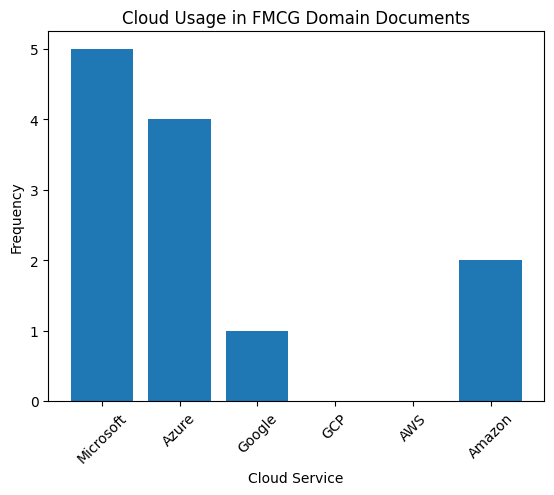

In [ ]:
import docx
import matplotlib.pyplot as plt

# Function to extract text from a docx file
def read_docx(fmcg_processed_docs):
    doc = docx.Document(fmcg_processed_docs)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# List of cloud-related keywords
cloud_keywords = ["Microsoft", "Azure", "Google", "GCP", "AWS", "Amazon"]

# Dictionary to store the cloud usage count
cloud_usage = {keyword: 0 for keyword in cloud_keywords}

# Loop through each document and check for cloud-related keywords
for doc_path in fmcg_docs:
    doc_text = read_docx(doc_path)
    for keyword in cloud_keywords:
        if keyword.lower() in doc_text.lower():
            cloud_usage[keyword] += 1

# Visualize the cloud usage
plt.bar(cloud_usage.keys(), cloud_usage.values())
plt.xlabel('Cloud Service')
plt.ylabel('Frequency')
plt.title('Cloud Usage in FMCG Domain Documents')
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


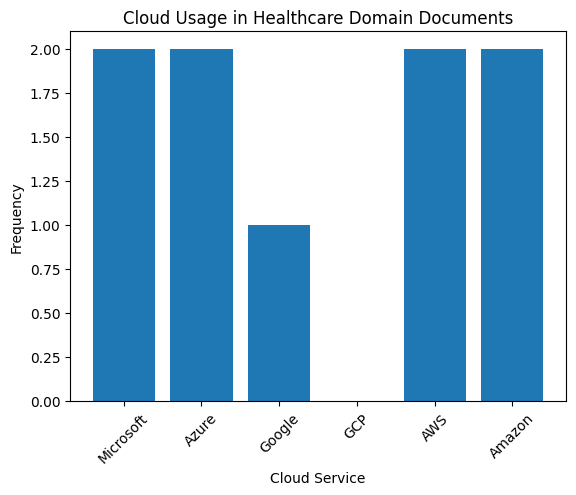

In [ ]:
import docx
import matplotlib.pyplot as plt

# Function to extract text from a docx file
def read_docx(healthcare_processed_docs):
    doc = docx.Document(healthcare_processed_docs)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# List of cloud-related keywords
cloud_keywords = ["Microsoft", "Azure", "Google", "GCP", "AWS", "Amazon"]

# Dictionary to store the cloud usage count
cloud_usage = {keyword: 0 for keyword in cloud_keywords}

# Loop through each document and check for cloud-related keywords
for doc_path in healthcare_docs:
    doc_text = read_docx(doc_path)
    for keyword in cloud_keywords:
        if keyword.lower() in doc_text.lower():
            cloud_usage[keyword] += 1

# Visualize the cloud usage
plt.bar(cloud_usage.keys(), cloud_usage.values())
plt.xlabel('Cloud Service')
plt.ylabel('Frequency')
plt.title('Cloud Usage in Healthcare Domain Documents')
plt.xticks(rotation=45)
plt.show()



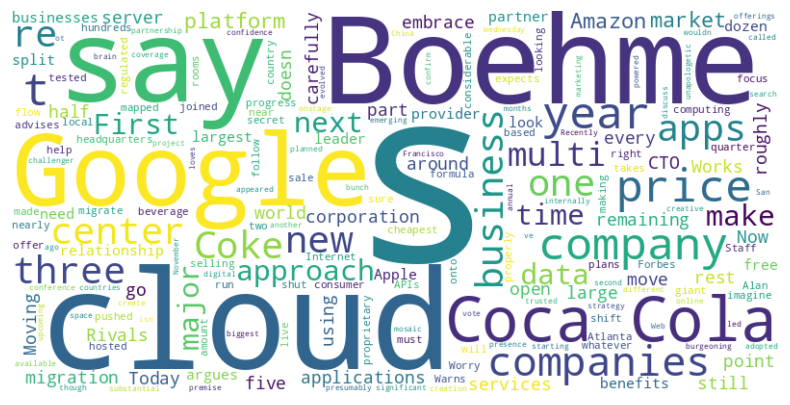

In [ ]:
import docx
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to extract text from multiple docx files
def read_multiple_docx(file_paths):
    full_text = ""
    for file_path in file_paths:
        doc = docx.Document(file_path)
        for para in doc.paragraphs:
            full_text += para.text + "\n"
    return full_text

# List of article file paths
article_paths = ["//content//Coca cola.docx"]

# Read all the articles and combine them into a single text
all_articles_text = read_multiple_docx(article_paths)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_articles_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


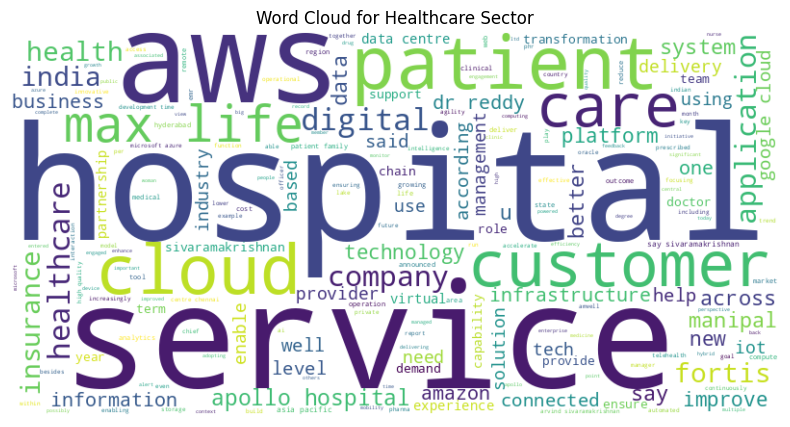

/usr/local/lib/python3.10/dist-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


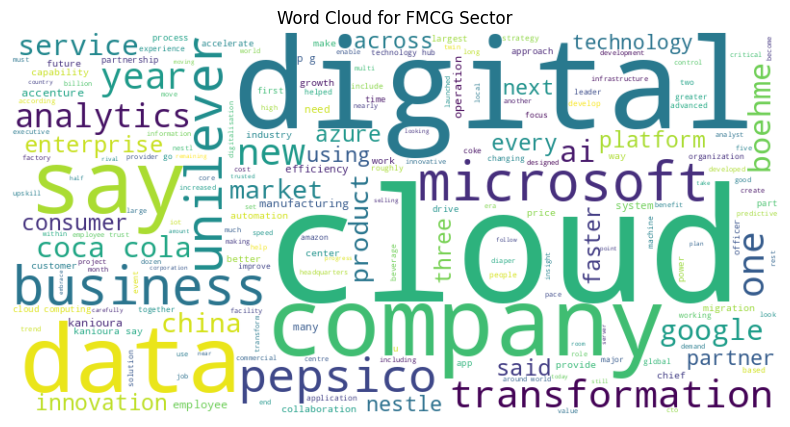

In [ ]:
import docx
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to extract text from a docx file
def read_docx(file_path):
    doc = docx.Document(file_path)
    full_text = ""
    for para in doc.paragraphs:
        full_text += para.text + "\n"
    return full_text
# Combine the preprocessed text of healthcare articles into a single text
all_healthcare_articles_text = " ".join([" ".join(doc) for doc in healthcare_processed_docs])

# Combine the preprocessed text of FMCG articles into a single text
all_fmcg_articles_text = " ".join([" ".join(doc) for doc in fmcg_processed_docs])

# Generate the word cloud for healthcare articles
wordcloud_healthcare = WordCloud(width=800, height=400, background_color='white').generate(all_healthcare_articles_text)

# Display the word cloud for healthcare articles
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_healthcare, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Healthcare Sector')
plt.show()

# Generate the word cloud for FMCG articles
wordcloud_fmcg = WordCloud(width=800, height=400, background_color='white').generate(all_fmcg_articles_text)

# Display the word cloud for FMCG articles
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fmcg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for FMCG Sector')
plt.show()


In [ ]:
import re
import docx
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Function to clean and preprocess text from a docx file
def clean_text(doc):
    # Read the docx file
    doc_content = docx.Document(doc)
    text = ""
    for paragraph in doc_content.paragraphs:
        text += paragraph.text + " "

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return words

# Preprocess healthcare domain documents
healthcare_processed_docs = [clean_text(doc) for doc in healthcare_docs]

# Create a dictionary and corpus for the healthcare domain
dictionary_healthcare = corpora.Dictionary(healthcare_processed_docs)
corpus_healthcare = [dictionary_healthcare.doc2bow(doc) for doc in healthcare_processed_docs]

# Number of topics to extract
num_topics_healthcare = 5

# Topic modeling using LDA for healthcare domain
lda_model_healthcare = LdaModel(corpus=corpus_healthcare, id2word=dictionary_healthcare, num_topics=num_topics_healthcare)

# Print the topics for healthcare domain
print("Healthcare Domain Topics:")
for idx, topic in lda_model_healthcare.print_topics():
    print(f"Topic {idx+1}: {topic}")

# Save the visualization as an HTML file
vis_healthcare = gensimvis.prepare(lda_model_healthcare, corpus_healthcare, dictionary_healthcare)
pyLDAvis.save_html(vis_healthcare, 'Healthcare_topics_visualization.html')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Healthcare Domain Topics:
Topic 1: 0.016*"hospital" + 0.011*"life" + 0.010*"service" + 0.010*"patient" + 0.010*"cloud" + 0.010*"aws" + 0.009*"max" + 0.009*"say" + 0.009*"customer" + 0.008*"healthcare"
Topic 2: 0.020*"hospital" + 0.014*"patient" + 0.013*"cloud" + 0.011*"max" + 0.011*"life" + 0.010*"customer" + 0.009*"aws" + 0.009*"say" + 0.009*"data" + 0.008*"service"
Topic 3: 0.018*"hospital" + 0.014*"patient" + 0.013*"fortis" + 0.011*"service" + 0.010*"cloud" + 0.010*"aws" + 0.010*"application" + 0.009*"care" + 0.006*"manipal" + 0.006*"platform"
Topic 4: 0.011*"cloud" + 0.010*"service" + 0.009*"aws" + 0.009*"patient" + 0.009*"hospital" + 0.007*"manipal" + 0.007*"google" + 0.007*"care" + 0.006*"digital" + 0.006*"also"
Topic 5: 0.014*"aws" + 0.013*"service" + 0.012*"customer" + 0.012*"cloud" + 0.010*"life" + 0.010*"hospital" + 0.008*"max" + 0.008*"data" + 0.007*"digital" + 0.007*"patient"
